# Importation des données

In [1]:
#importation des fichiers csv depuis le drive
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/OC/df_OC-11_data.csv',sep=',')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 12 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Nom                                             150 non-null    object 
 1   Code_ISO3                                       150 non-null    object 
 2   Croissance sur 5 ans                            150 non-null    float64
 3   PIB par habitant                                150 non-null    float64
 4   Stabilité politique 2017                        150 non-null    float64
 5   SP sur 5 ans                                    150 non-null    float64
 6   Average tariff (estimated) faced by France (%)  150 non-null    float64
 7   Distance_from_France_km                         150 non-null    float64
 8   Pop ayant elec 2017                             150 non-null    float64
 9   Accord-EU                                  

# ACP

Faire une Analyse en Composantes Principales (ACP / PCA) sur les variables numériques du DataFrame df pour réduire le nombre de dimensions des données.

## Sélectionner les colonnes


Je vais utiliser la fonction select_dtypes pour sélectionner les colonnes qui contiennent des nombres (float ou integer).


In [3]:
df_numerical = df.select_dtypes(include=['float64', 'int64'])
df_numerical.head()

,Croissance sur 5 ans,PIB par habitant,Stabilité politique 2017,SP sur 5 ans,Average tariff (estimated) faced by France (%),Distance_from_France_km,Pop ayant elec 2017,Accord-EU,Disponibilité Volailles (par habitant),Importation volailles (par habitant)
0,0.164779,449.349898,-2.794976,0.155636,5.0,5581.149309,97.7,0,0.001570,0.000799
1,0.079063,5659.599010,-0.284804,10.218615,0.0,9341.821999,84.4,0,0.037152,0.009016
2,-0.010270,4281.135736,0.373771,-3.602288,0.2,1600.850853,99.9,0,0.016296,0.013175
3,0.107140,3894.875611,-0.919614,-0.305974,8.4,1347.074786,99.5,1,0.006693,0.000048
4,0.020819,38954.963357,0.574381,-0.259457,0.0,877.998427,100.0,1,0.021038,0.010187


## Mettre les données à l’échelle

Standardiser les variables numériques sélectionnées en utilisant StandardScaler.

Cela permet de mettre toutes les variables sur la même échelle, afin que chacune ait la même importance dans la PCA, peu importe leurs valeurs d’origine.

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled_array = scaler.fit_transform(df_numerical)
df_scaled = pd.DataFrame(df_scaled_array, columns=df_numerical.columns)
df_scaled.head()

,Croissance sur 5 ans,PIB par habitant,Stabilité politique 2017,SP sur 5 ans,Average tariff (estimated) faced by France (%),Distance_from_France_km,Pop ayant elec 2017,Accord-EU,Disponibilité Volailles (par habitant),Importation volailles (par habitant)
0,1.396691,-0.694152,-3.215238,-0.058398,-0.073824,-0.011861,0.525813,-0.644278,-1.122570,-0.567288
1,0.129546,-0.358688,-0.248834,0.725654,-0.372947,1.049902,0.013757,-0.644278,0.813539,-0.075033
2,-1.191062,-0.447441,0.529438,-0.351195,-0.360982,-1.135631,0.610514,-0.644278,-0.321301,0.174142
3,0.544606,-0.472311,-0.999024,-0.094364,0.129580,-1.207281,0.595114,1.552125,-0.843853,-0.612258
4,-0.731473,1.785046,0.766510,-0.090740,-0.372947,-1.339716,0.614364,1.552125,-0.063241,-0.004912


## Analyse

Maintenant, je vais appliquer l’Analyse en Composantes Principales (PCA) sur ces données pour réduire le nombre de dimensions tout en gardant le plus d’informations possible.

In [5]:
from sklearn.decomposition import PCA

pca = PCA()
principal_components = pca.fit_transform(df_scaled)

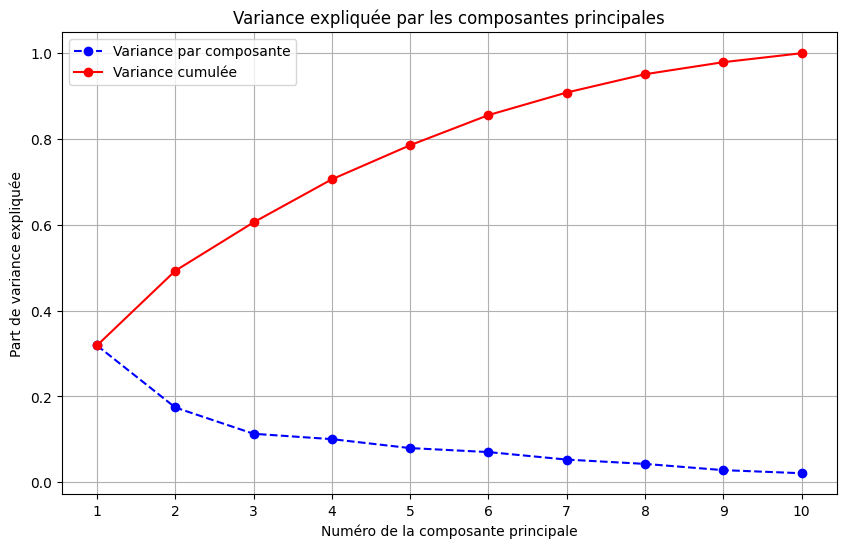

In [6]:
import matplotlib.pyplot as plt
import numpy as np

variance_cumulee = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker='o', linestyle='--', color='blue',
    label='Variance par composante'
)

plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    variance_cumulee,
    marker='o', linestyle='-', color='red',
    label='Variance cumulée'
)

plt.title('Variance expliquée par les composantes principales')
plt.xlabel('Numéro de la composante principale')
plt.ylabel('Part de variance expliquée')

plt.grid(True)
plt.legend()

plt.xticks(np.arange(1, len(pca.explained_variance_ratio_) + 1, 1))

plt.show()


Mes variables sont très variées, l’information est diluée sur beaucoup d’axes…
Pour atteindre l'objectif des 60 % de variance expliquée, il est nécessaire de passer à 3 composantes principales au lieu de 2, comme l'indique le graphique (le point 3 sur la courbe rouge se situe exactement sur la ligne du 0.6).
Même si nous n'utilisons que 60% de la variance, ces deux axes capturent l'essentiel de la structure du marché.


##Cercle de corrélation

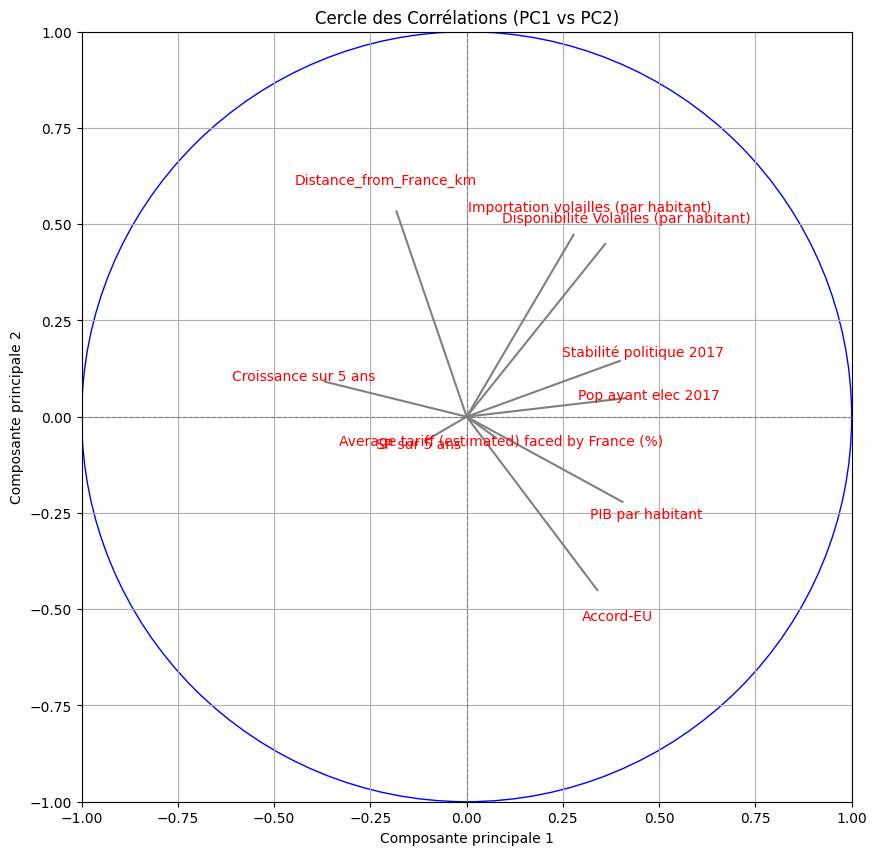

In [7]:
import matplotlib.pyplot as plt
import numpy as np

num_features = df_numerical.shape[1]

loadings = pca.components_

plt.figure(figsize=(10, 10))

for i, (x, y) in enumerate(zip(loadings[0, :], loadings[1, :])):
    plt.plot([0, x], [0, y], color='grey')
    plt.text(x * 1.15, y * 1.15, df_numerical.columns[i], color='red', ha='center', va='center')

circle = plt.Circle((0, 0), 1, color='blue', fill=False)
plt.gca().add_artist(circle)

plt.xlim([-1, 1])
plt.ylim([-1, 1])
plt.xlabel('Composante principale 1')
plt.ylabel('Composante principale 2')
plt.title('Cercle des Corrélations (PC1 vs PC2)')
plt.grid(True)
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

CP 1 :

Contribution Positive : Un PIB par habitant élevé, un bon accès à l'électricité et une stabilité politique actuelle

Contribution Negative : La Croissance sur 5 ans et l'indice de Stabilité sur 5 ans



CP 2 :    

Contribution Positive : Distance, Importation de volailles et la Disponibilité de volailles

Contribution Négative : Accord-EU



Cible : pays qui se projettent dans la zone "Sud-Est" du graphique car ils combinent :

Richesse et Stabilité (CP1+)

Facilité d'accès et Accords commerciaux (CP2-)


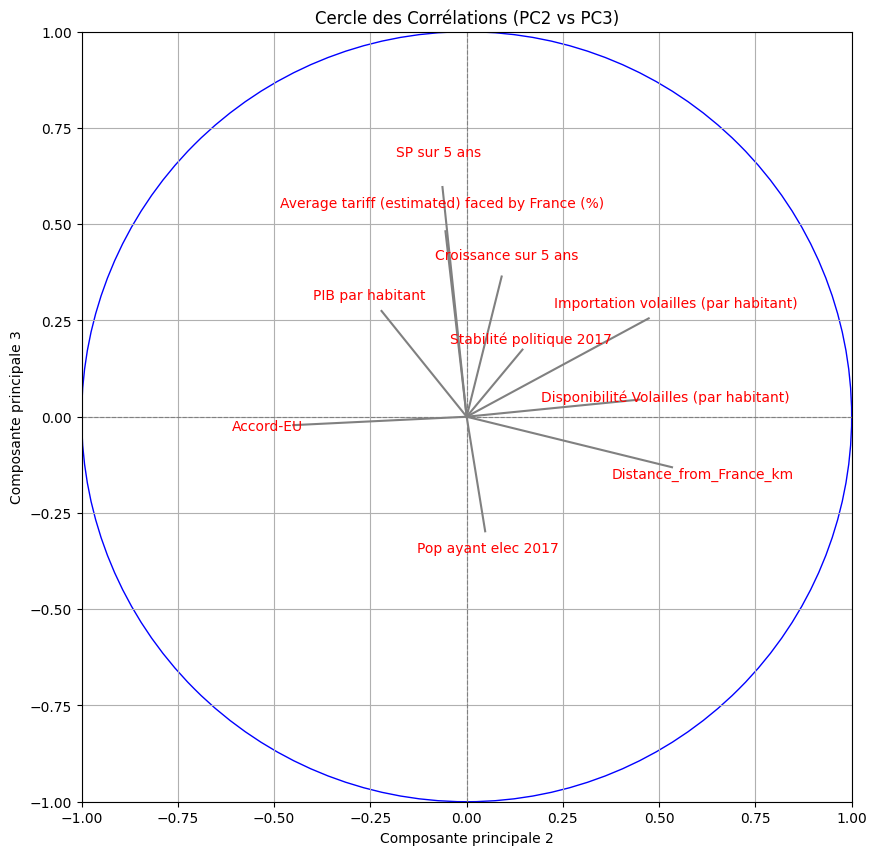

In [8]:
import matplotlib.pyplot as plt
import numpy as np

num_features = df_numerical.shape[1]

loadings = pca.components_

plt.figure(figsize=(10, 10))

# PC2 vs PC3
for i, (x, y) in enumerate(zip(loadings[1, :], loadings[2, :])):
    plt.plot([0, x], [0, y], color='grey')
    plt.text(x * 1.15, y * 1.15, df_numerical.columns[i], color='red', ha='center', va='center')

circle = plt.Circle((0, 0), 1, color='blue', fill=False)
plt.gca().add_artist(circle)

plt.xlim([-1, 1])
plt.ylim([-1, 1])
plt.xlabel('Composante principale 2')
plt.ylabel('Composante principale 3')
plt.title('Cercle des Corrélations (PC2 vs PC3)')
plt.grid(True)
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

CP2 :    

Contribution Positive : la distance par rapport à la France, la disponibilité et l’importation de volailles

Contribution Négative : Accord-EU

CP3 :    

Contribution Positive : la stabilité politique sur 5 ans, la croissance sur 5 ans et les taxes

Contribution Négative : accès à l'électricité

Cible : zone "Nord-Ouest" car elle regroupe des pays :

Sûrs et Stables (CP3+)

Proches commercialement de la France (CP2-)

# Clustering

##Méthode du coude K-means

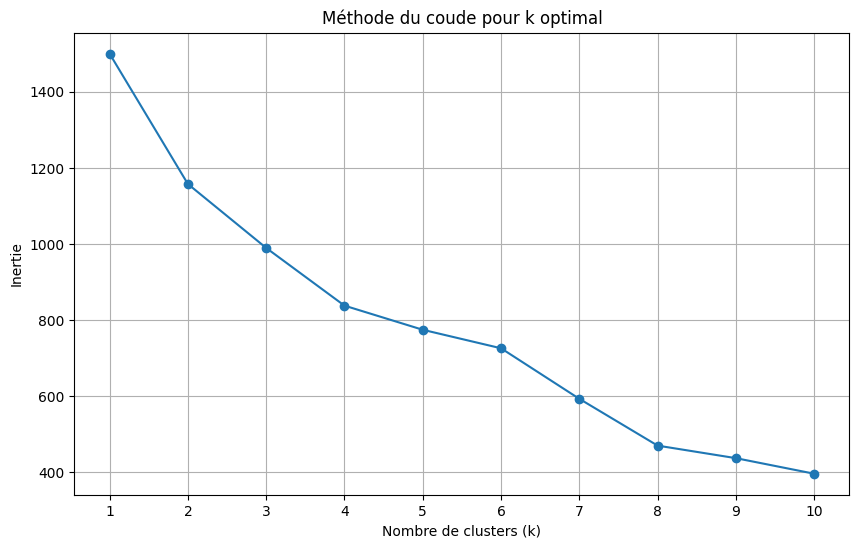

In [9]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia_values = []

k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(principal_components)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia_values, marker='o')
plt.title('Méthode du coude pour k optimal')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie')
plt.xticks(k_range)
plt.grid(True)
plt.show()

Le choix de 4 clusters est le meilleur compromis : mathématiquement, c'est là que l'on gagne le plus en cohérence de groupe (inertie), et stratégiquement, cela nous permet de bien isoler nos 'champions' sans fragmenter les données inutilement.

## Centroïdes

In [10]:
optimal_clusters = 4  # D'après le graphique

kmeans = KMeans(n_clusters=optimal_clusters, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(principal_components)

print(f"Étiquettes de cluster générées pour {optimal_clusters} clusters.")
print(f"Premières 10 étiquettes de cluster : {cluster_labels[:10]}")

Étiquettes de cluster générées pour 4 clusters.
Premières 10 étiquettes de cluster : [0 3 3 3 2 0 1 3 3 3]


Graphique de dispersion des deux premières composantes principales, en coloriant chaque point selon le cluster qui lui a été attribué


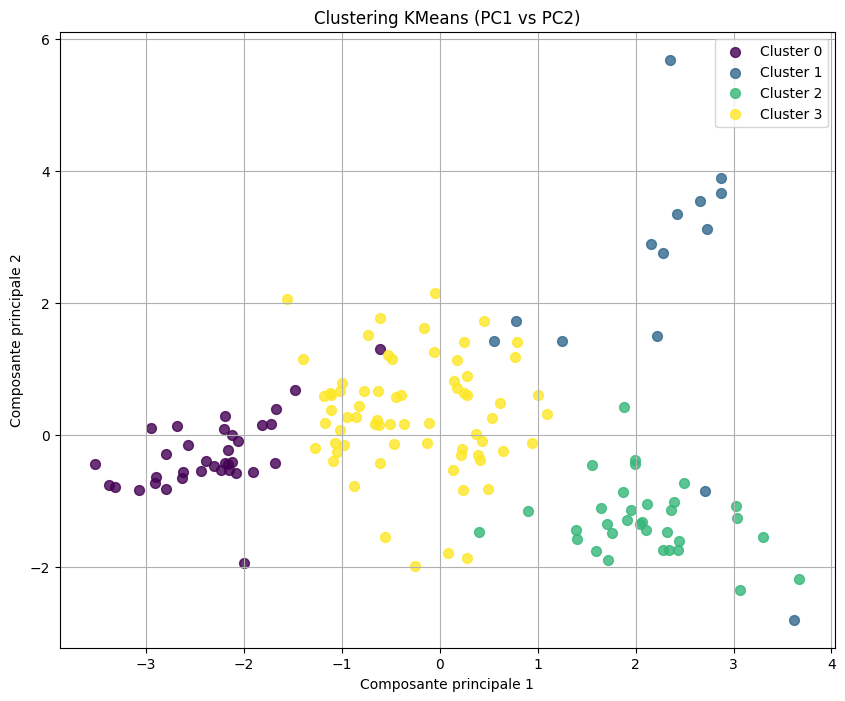

In [11]:
plt.figure(figsize=(10, 8))
colors = plt.cm.viridis(np.linspace(0, 1, optimal_clusters))

for i in range(optimal_clusters):
    # On ne trace que les points appartenant au cluster i
    points = principal_components[cluster_labels == i]
    plt.scatter(points[:, 0], points[:, 1], color=colors[i], label=f'Cluster {i}', s=50, alpha=0.8)

plt.title('Clustering KMeans (PC1 vs PC2)')
plt.xlabel('Composante principale 1')
plt.ylabel('Composante principale 2')
plt.legend()
plt.grid(True)
plt.show()

Le Cluster Gagnant : Le Cluster 2 (Vert)
C'est sans aucun doute celui qu'on doit privilégier

Position : Il est situé exactement là où nous voulions : à droite sur l'axe 1 (CP1 > 0) et en bas sur l'axe 2 (CP2 < 0).

Rappel :    

Cible : pays qui se projettent dans la zone "Sud-Est" du graphique car ils combinent :

Richesse et Stabilité (CP1+)

Facilité d'accès et Accords commerciaux (CP2-)

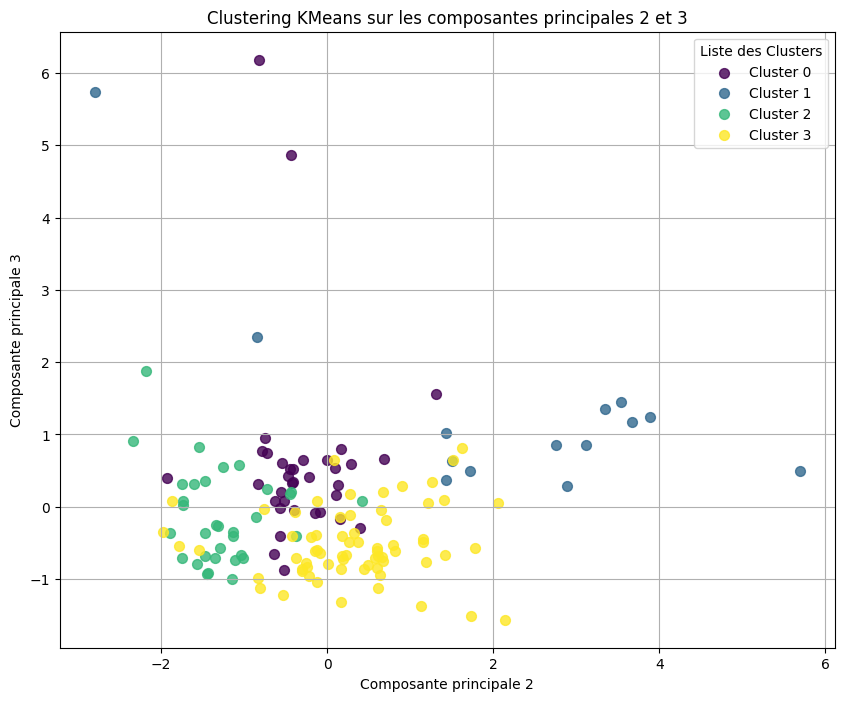

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# On définit le nombre de clusters (assure-toi que cette variable existe)
# optimal_clusters = 4

plt.figure(figsize=(10, 8))

# 1. On génère la palette de couleurs viridis de manière fixe
colors = plt.cm.viridis(np.linspace(0, 1, optimal_clusters))

# 2. On trace chaque cluster un par un pour garantir la correspondance couleur/légende
for i in range(optimal_clusters):
    # On sélectionne uniquement les points du cluster i
    indices = np.where(cluster_labels == i)
    plt.scatter(principal_components[indices, 1], # Axe X : PC2
                principal_components[indices, 2], # Axe Y : PC3
                color=colors[i],
                label=f'Cluster {i}',
                s=50,
                alpha=0.8)

plt.title('Clustering KMeans sur les composantes principales 2 et 3')
plt.xlabel('Composante principale 2')
plt.ylabel('Composante principale 3')

plt.legend(title="Liste des Clusters")
plt.grid(True)
plt.show()

Encore une fois, c'est le Cluster 2 qui ressort comme la cible idéale

Il occupe majoritairement le quadrant Nord-Ouest (CP2 négatif et CP3 proche de 0 ou positif).

Rappel :    

Cible : zone "Nord-Ouest" car elle regroupe des pays :

Sûrs et Stables (CP3+)

Proches commercialement de la France (CP2-)

In [13]:
df['Cluster'] = cluster_labels
df.head()

,Nom,Code_ISO3,Croissance sur 5 ans,PIB par habitant,Stabilité politique 2017,SP sur 5 ans,Average tariff (estimated) faced by France (%),Distance_from_France_km,Pop ayant elec 2017,Accord-EU,Disponibilité Volailles (par habitant),Importation volailles (par habitant),Cluster
0,Afghanistan,AFG,0.164779,449.349898,-2.794976,0.155636,5.0,5581.149309,97.7,0,0.001570,0.000799,0
1,Afrique du Sud,ZAF,0.079063,5659.599010,-0.284804,10.218615,0.0,9341.821999,84.4,0,0.037152,0.009016,3
2,Albanie,ALB,-0.010270,4281.135736,0.373771,-3.602288,0.2,1600.850853,99.9,0,0.016296,0.013175,3
3,Algérie,DZA,0.107140,3894.875611,-0.919614,-0.305974,8.4,1347.074786,99.5,1,0.006693,0.000048,3
4,Allemagne,DEU,0.020819,38954.963357,0.574381,-0.259457,0.0,877.998427,100.0,1,0.021038,0.010187,2


## ACH

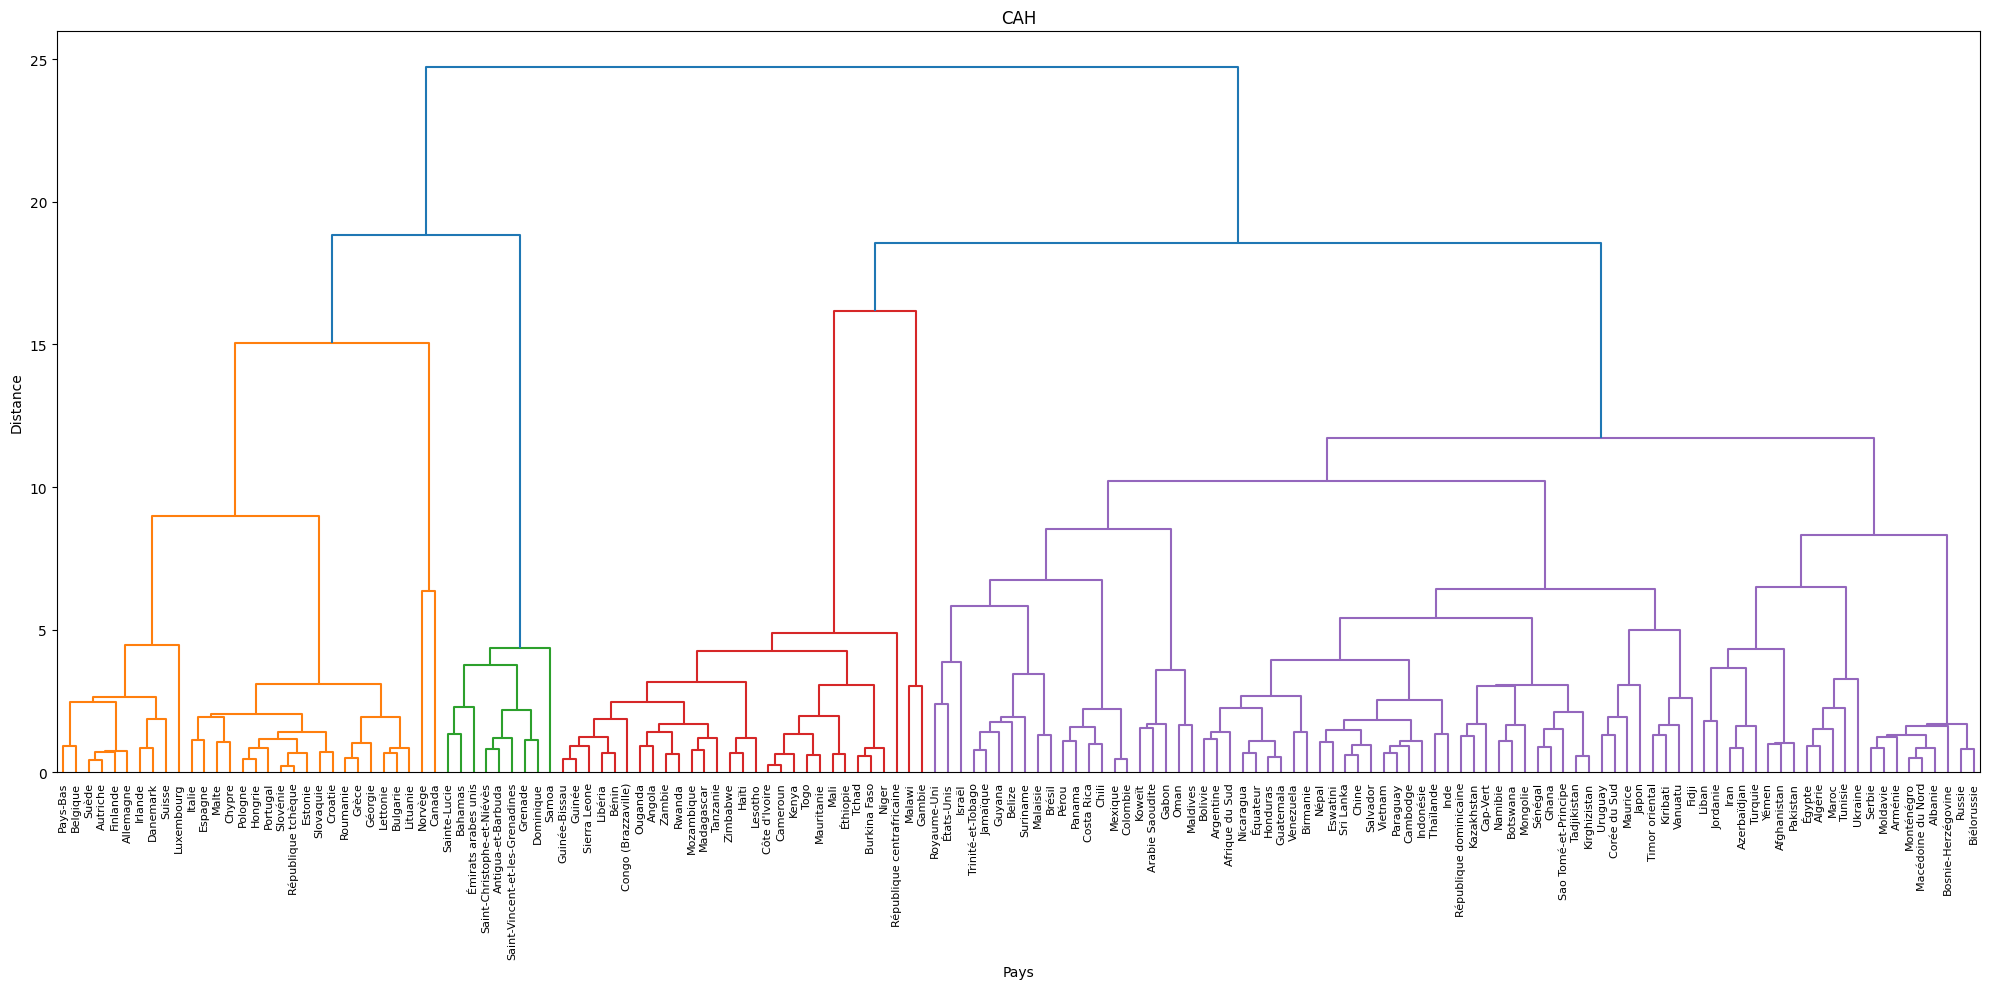

In [14]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

linked = linkage(principal_components, method='ward')

plt.figure(figsize=(20, 10))
dendrogram(
    linked,
    orientation='top',
    labels=df['Nom'].tolist(),
    distance_sort='descending',
    show_leaf_counts=False,
    leaf_rotation=90,
    leaf_font_size=8
)
plt.title('CAH')
plt.xlabel('Pays')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

Sur ce graphique, on voit que les pays se regroupent naturellement par "familles" de couleurs selon leurs ressemblances. Cela prouve que notre classement est cohérent.
À gauche,  les pays les plus riches et stables : ce sont nos clients idéaux. À l'inverse, à l'autre bout du graphique, on trouve des pays beaucoup plus instables où l'économie est difficile.


# Boxplot

Pour comprendre les caractéristiques de chaque cluster, nous allons calculer la moyenne des variables numériques d'origine pour chaque cluster.

In [15]:
cluster_analysis = df.groupby('Cluster')[df_numerical.columns].mean()
display(cluster_analysis)

,Croissance sur 5 ans,PIB par habitant,Stabilité politique 2017,SP sur 5 ans,Average tariff (estimated) faced by France (%),Distance_from_France_km,Pop ayant elec 2017,Accord-EU,Disponibilité Volailles (par habitant),Importation volailles (par habitant)
Cluster,,,,,,,,,,
0,0.147644,1550.783009,-0.841002,5.494232,5.502857,5675.878602,44.368571,0.028571,0.005710,0.003546
1,0.049882,20191.636359,0.763577,0.071776,28.771429,6829.675767,98.885714,0.142857,0.057421,0.049239
2,0.012461,29292.894377,0.599873,-0.455508,0.293939,1795.278894,99.942424,0.939394,0.025305,0.011406
3,0.062762,5602.326002,-0.179218,-0.624982,4.852941,7205.269637,93.691176,0.147059,0.021931,0.005153


/tmp/ipykernel_60124/2138613919.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=column, data=df, ax=axes[i], palette='viridis')
/tmp/ipykernel_60124/2138613919.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=column, data=df, ax=axes[i], palette='viridis')
/tmp/ipykernel_60124/2138613919.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=column, data=df, ax=axes[i], palette='viridis')
/tmp/ipykernel_60124/2138613919.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is de

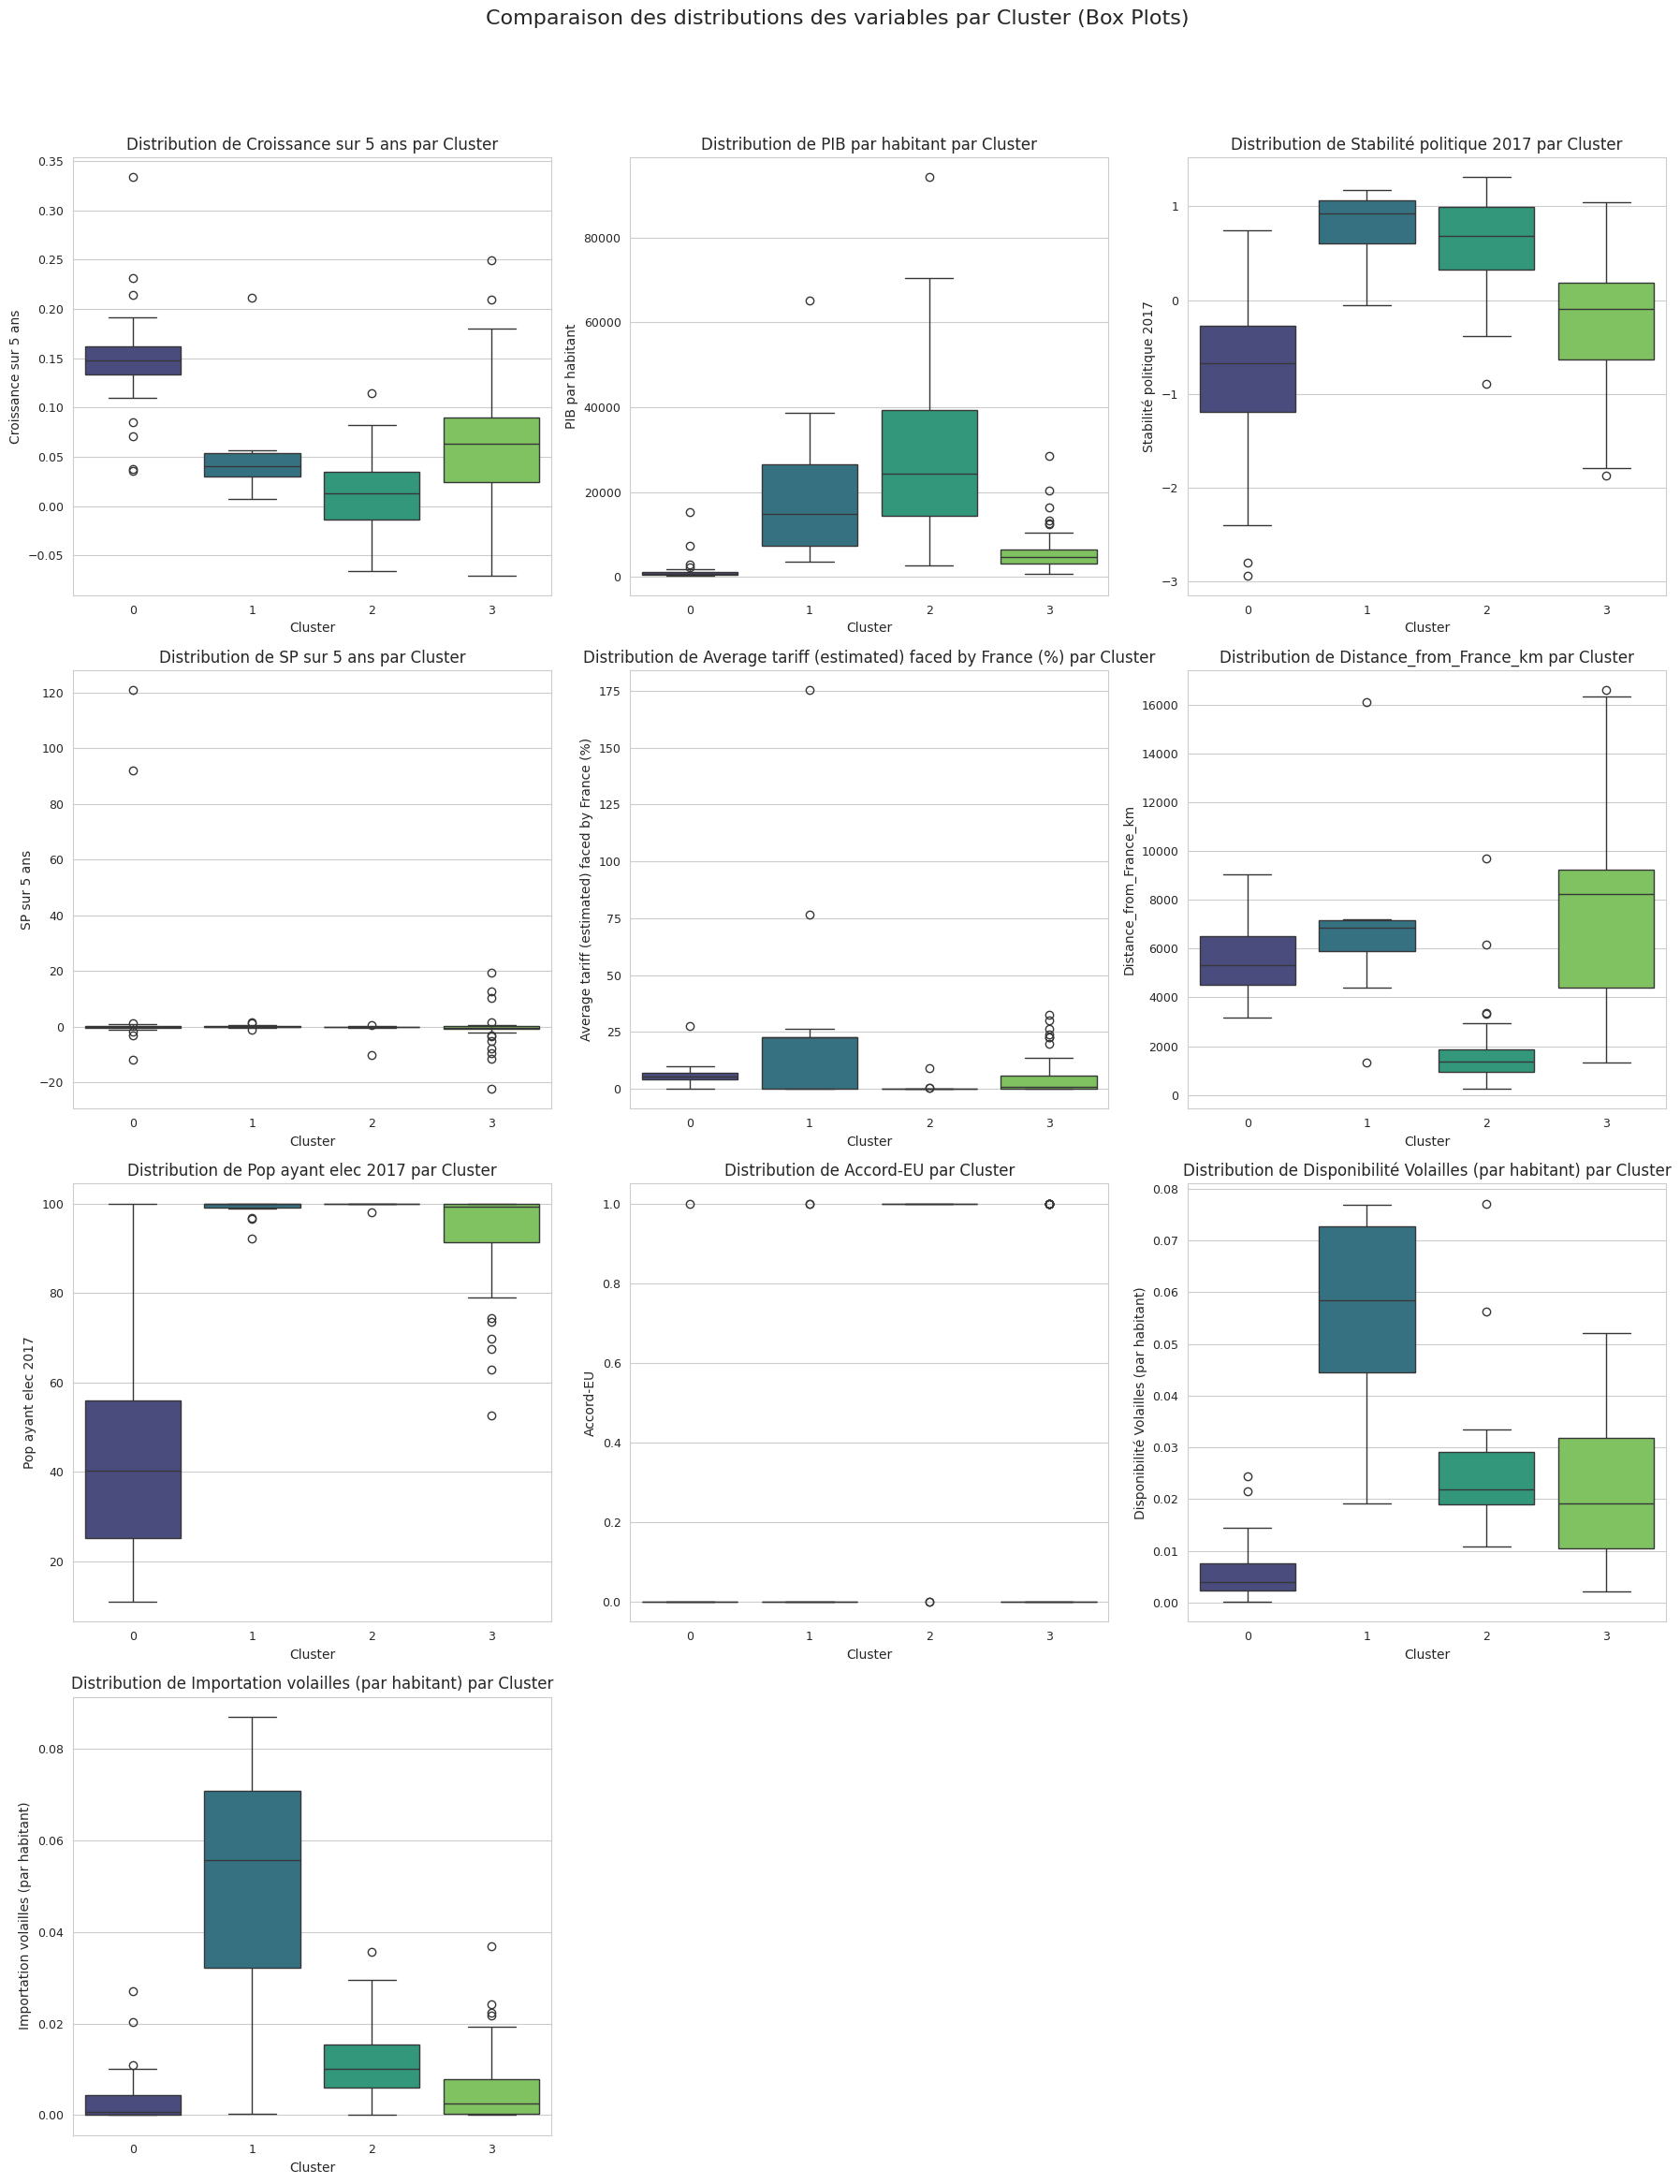

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

df_numerical = df.select_dtypes(include=['float64', 'int64'])
columns_to_plot = df_numerical.columns

sns.set_style("whitegrid")

num_cols = len(columns_to_plot)
num_rows = (num_cols + 2) // 3

fig, axes = plt.subplots(num_rows, 3, figsize=(18, num_rows * 6))
axes = axes.flatten()

for i, column in enumerate(columns_to_plot):
    if i < len(axes):
        sns.boxplot(x='Cluster', y=column, data=df, ax=axes[i], palette='viridis')
        axes[i].set_title(f'Distribution de {column} par Cluster', fontsize=12)
        axes[i].set_xlabel('Cluster', fontsize=10)
        axes[i].set_ylabel(column, fontsize=10)
        axes[i].tick_params(axis='x', labelsize=9)
        axes[i].tick_params(axis='y', labelsize=9)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle('Comparaison des distributions des variables par Cluster (Box Plots)', y=1.00, fontsize=16)
plt.show()

In [17]:
df.loc[df['Cluster'] == 0]

,Nom,Code_ISO3,Croissance sur 5 ans,PIB par habitant,Stabilité politique 2017,SP sur 5 ans,Average tariff (estimated) faced by France (%),Distance_from_France_km,Pop ayant elec 2017,Accord-EU,Disponibilité Volailles (par habitant),Importation volailles (par habitant),Cluster
0,Afghanistan,AFG,0.164779,449.349898,-2.794976,0.155636,5.0,5581.149309,97.7,0,0.001570,0.000799,0
5,Angola,AGO,0.187544,2386.453625,-0.387895,-0.003665,0.0,6502.958533,42.9,0,0.010699,0.009290,0
15,Bénin,BEN,0.148619,902.149889,0.026252,-0.927951,6.9,4724.809971,34.5,0,0.014407,0.011007,0
23,Burkina Faso,BFA,0.158225,606.372102,-0.927886,0.618982,6.9,4073.609058,17.0,0,0.002397,0.000000,0
25,Cameroun,CMR,0.143392,1279.365074,-1.091505,0.854669,5.6,5077.719888,60.9,0,0.003338,0.000000,0
32,Congo (Brazzaville),COG,0.133142,1891.254574,-0.533615,0.089700,7.6,6038.455502,46.2,0,0.021523,0.020349,0
35,Côte d'Ivoire,CIV,0.134137,1679.749704,-1.091116,-0.136407,6.9,4875.650762,65.6,0,0.002660,0.000286,0
46,Éthiopie,ETH,0.147454,595.474969,-1.677231,0.072212,4.9,5573.055421,44.3,0,0.000132,0.000009,0
50,Gambie,GMB,0.162139,549.446418,-0.094831,120.759452,6.9,4306.454756,56.2,0,0.003614,0.007227,0
56,Guinée,GIN,0.132884,712.843015,-0.699074,-0.456824,6.9,4615.377592,35.4,0,0.004143,0.003066,0


In [18]:
df.loc[df['Cluster'] == 1]

,Nom,Code_ISO3,Croissance sur 5 ans,PIB par habitant,Stabilité politique 2017,SP sur 5 ans,Average tariff (estimated) faced by France (%),Distance_from_France_km,Pop ayant elec 2017,Accord-EU,Disponibilité Volailles (par habitant),Importation volailles (par habitant),Cluster
6,Antigua-et-Barbuda,ATG,0.055492,14508.062962,0.732061,-0.249775,22.6,6705.905907,100.0,0,0.073355,0.073355,1
12,Bahamas,BHS,0.049977,27257.985441,0.976763,-0.175050,0.0,7206.906204,100.0,0,0.068107,0.062868,1
26,Canada,CAN,0.051832,38592.122556,1.089681,-0.020966,76.6,5649.091630,100.0,1,0.039012,0.004955,1
38,Dominique,DMA,0.006947,7033.221281,1.172777,0.195996,22.6,6821.376498,98.9,0,0.055977,0.055977,1
40,Émirats arabes unis,ARE,0.037806,37398.340370,0.601950,-0.302695,0.0,5239.255397,100.0,0,0.043427,0.045640,1
54,Grenade,GRD,0.031904,8338.828982,0.992375,1.014366,26.5,7116.683451,92.2,0,0.072154,0.063135,1
75,Koweït,KWT,0.211191,24839.792726,-0.051229,-1.251609,0.0,4405.216004,100.0,0,0.046596,0.033776,1
101,Norvège,NOR,0.056369,65103.333678,1.150702,-0.133162,175.3,1341.704258,100.0,1,0.019259,0.000378,1
118,Saint-Christophe-et-Niévès,KNA,0.043258,19210.697762,0.628550,-0.355854,11.3,6755.339279,100.0,0,0.076857,0.076857,1
119,Sainte-Lucie,LCA,0.024388,9691.390783,0.974611,0.090528,0.0,6899.881673,99.9,0,0.060789,0.055263,1


In [19]:
df.loc[df['Cluster'] == 2]

,Nom,Code_ISO3,Croissance sur 5 ans,PIB par habitant,Stabilité politique 2017,SP sur 5 ans,Average tariff (estimated) faced by France (%),Distance_from_France_km,Pop ayant elec 2017,Accord-EU,Disponibilité Volailles (par habitant),Importation volailles (par habitant),Cluster
4,Allemagne,DEU,0.020819,38954.963357,0.574381,-0.259457,0.0,877.998427,100.0,1,0.021038,0.010187,2
10,Autriche,AUT,0.037364,40331.573950,1.029625,-0.231948,0.0,1033.297693,100.0,1,0.019615,0.012472,2
13,Belgique,BEL,0.030165,37656.339949,0.417607,-0.547848,0.0,263.572203,100.0,1,0.013310,0.029598,2
22,Bulgarie,BGR,-0.031573,7436.881567,0.321380,-0.153894,0.0,1757.417304,98.1,1,0.022105,0.015206,2
30,Chypre,CYP,0.039322,22445.227654,0.530974,-0.163986,0.0,2950.586561,100.0,1,0.032212,0.011868,2
36,Croatie,HRV,-0.026309,11887.966320,0.681906,0.123604,0.0,1079.325263,100.0,1,0.010758,0.005738,2
37,Danemark,DNK,0.021631,49188.944330,0.854938,-0.065551,0.0,1026.548013,100.0,1,0.029133,0.023202,2
42,Espagne,ESP,-0.008831,24270.003899,0.270846,-10.176102,0.0,1052.879631,100.0,1,0.032092,0.004395,2
43,Estonie,EST,-0.002848,17830.958055,0.642371,0.009279,0.0,1858.522975,100.0,1,0.021980,0.015916,2
45,États-Unis,USA,0.035157,50996.321566,0.262138,-0.585514,0.2,6165.609754,100.0,0,0.056188,0.000378,2


In [20]:
df.loc[df['Cluster'] == 3]

,Nom,Code_ISO3,Croissance sur 5 ans,PIB par habitant,Stabilité politique 2017,SP sur 5 ans,Average tariff (estimated) faced by France (%),Distance_from_France_km,Pop ayant elec 2017,Accord-EU,Disponibilité Volailles (par habitant),Importation volailles (par habitant),Cluster
1,Afrique du Sud,ZAF,0.079063,5659.599010,-0.284804,10.218615,0.0,9341.821999,84.4,0,0.037152,0.009016,3
2,Albanie,ALB,-0.010270,4281.135736,0.373771,-3.602288,0.2,1600.850853,99.9,0,0.016296,0.013175,3
3,Algérie,DZA,0.107140,3894.875611,-0.919614,-0.305974,8.4,1347.074786,99.5,1,0.006693,0.000048,3
7,Arabie Saoudite,SAU,0.135356,20462.879009,-0.649626,0.351449,0.0,4681.204040,100.0,0,0.043352,0.021812,3
8,Argentine,ARG,0.052256,12427.313948,0.162542,0.577458,1.0,11051.246560,100.0,0,0.044655,0.000182,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,Ukraine,UKR,-0.021254,2227.028902,-1.867418,19.237548,0.4,2023.195973,100.0,1,0.022680,0.002720,3
143,Uruguay,URY,0.017066,16405.550078,1.040092,0.466638,1.0,10954.746973,99.8,0,0.009602,0.000873,3
144,Vanuatu,VUT,0.144333,2702.121223,0.676285,-0.437227,0.0,16330.422890,62.8,0,0.010508,0.014010,3
145,Venezuela,VEN,0.001418,3242.116989,-1.252241,0.219162,1.0,7616.953989,99.2,0,0.021291,0.000850,3


Cluster 0 : On voit bien que c'est le groupe "difficile". Le PIB est bas, la stabilité politique est très faible (boîte en dessous de 0) et l'accès à l'électricité est aléatoire.
Cluster 3 : Ce sont des pays très lointains (voir le graphique Distance_from_France) avec une consommation moyenne. Le coût du transport risque d'y être trop élevé.



Alors que le Cluster 1 (bleu pétrole) offre certes une forte croissance et une forte importation, il est pénalisé par des distances énormes et des barrières tarifaires instables. Le Cluster 2, par sa stabilité, sa proximité et son opulence économique, représente le meilleur ratio bénéfice/risque pour un exportateur français.

# Synthèse

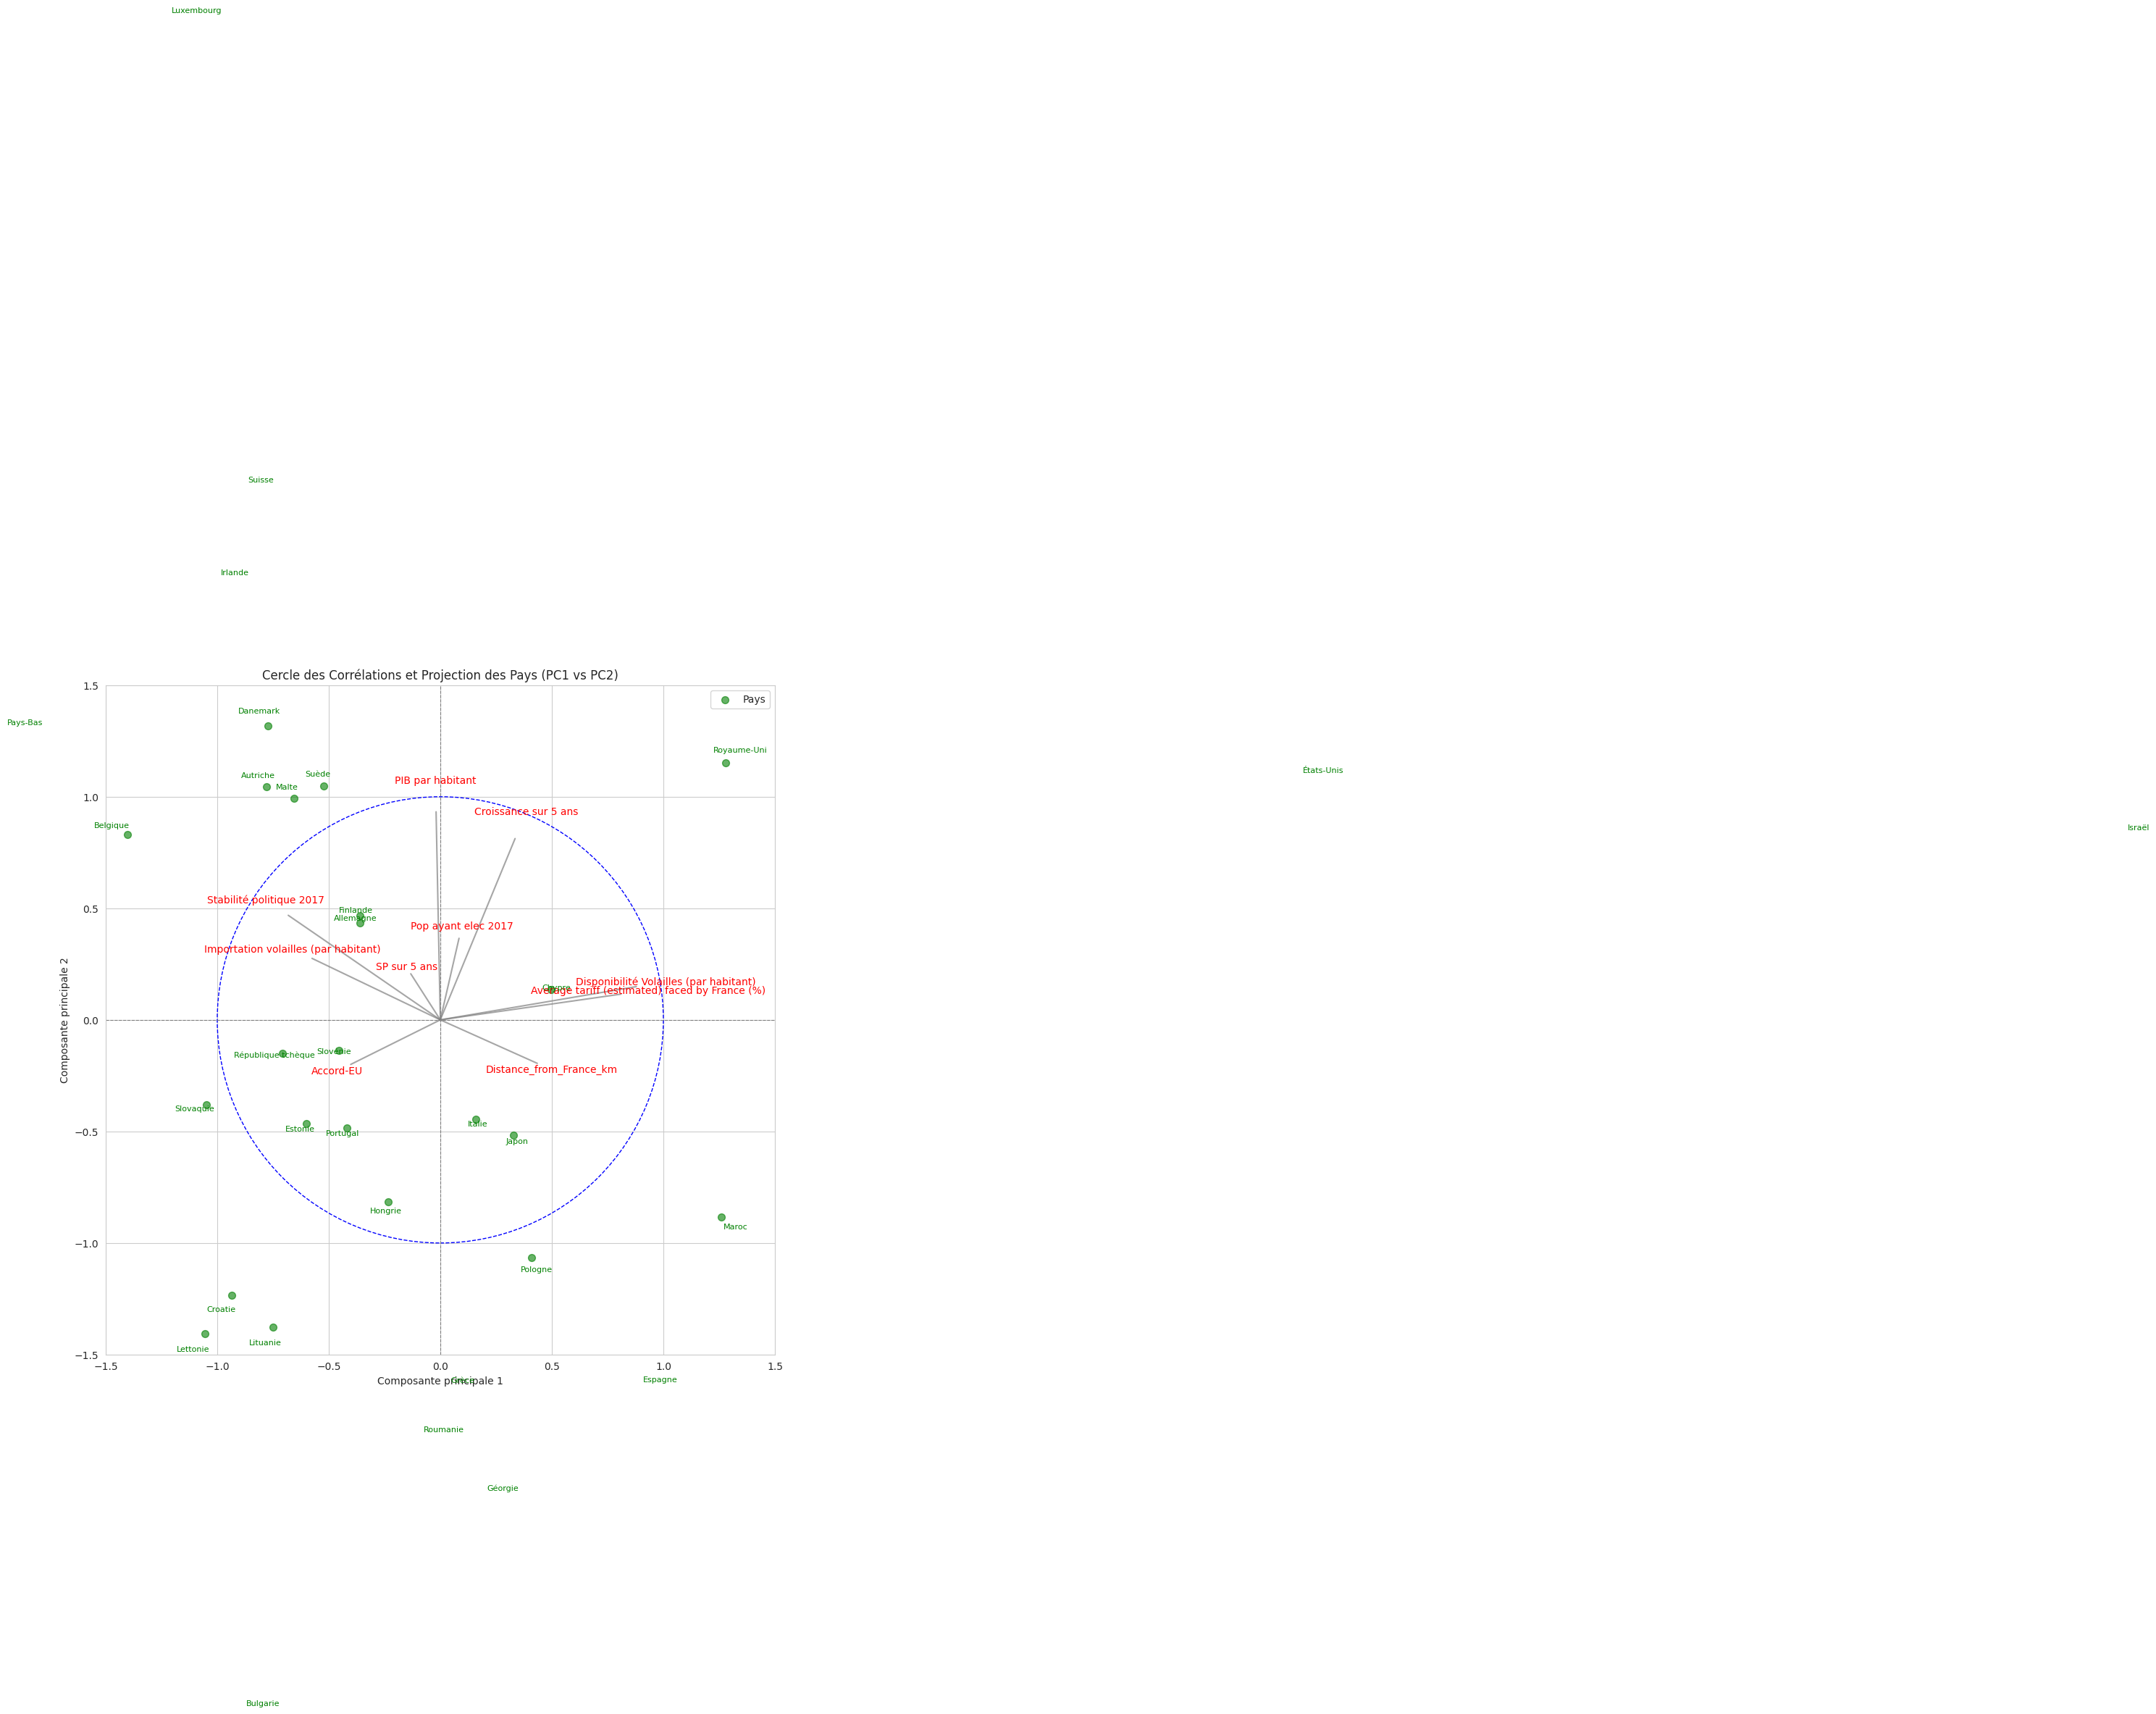

Nbr: 33 pays
Pays: ['Allemagne', 'Autriche', 'Belgique', 'Bulgarie', 'Chypre', 'Croatie', 'Danemark', 'Espagne', 'Estonie', 'États-Unis', 'Finlande', 'Géorgie', 'Grèce', 'Hongrie', 'Irlande', 'Israël', 'Italie', 'Japon', 'Lettonie', 'Lituanie', 'Luxembourg', 'Malte', 'Maroc', 'Pays-Bas', 'Pologne', 'Portugal', 'République tchèque', 'Roumanie', 'Royaume-Uni', 'Slovaquie', 'Slovénie', 'Suède', 'Suisse']


In [21]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

df_filtered = df[df['Cluster'] == 2].copy()

df_filtered_numerical = df_filtered.select_dtypes(include=['float64', 'int64']).drop(columns=['Cluster'], errors='ignore')

countries = df_filtered['Nom'].tolist()

scaler_filtered = StandardScaler()
df_filtered_scaled = scaler_filtered.fit_transform(df_filtered_numerical)

pca_filtered = PCA()
principal_components_filtered = pca_filtered.fit_transform(df_filtered_scaled)

loadings_filtered = pca_filtered.components_.T * np.sqrt(pca_filtered.explained_variance_)

plt.figure(figsize=(12, 12))

for i, (x, y) in enumerate(zip(loadings_filtered[:, 0], loadings_filtered[:, 1])):
    plt.plot([0, x], [0, y], color='grey', alpha=0.7)
    plt.text(x * 1.15, y * 1.15, df_filtered_numerical.columns[i], color='red', ha='center', va='center', fontsize=10)

circle = plt.Circle((0, 0), 1, color='blue', fill=False, linestyle='--')
plt.gca().add_artist(circle)

plt.scatter(principal_components_filtered[:, 0], principal_components_filtered[:, 1], c='green', s=50, alpha=0.6, label='Pays')

for i, country_name in enumerate(countries):
    x_coord = principal_components_filtered[i, 0]
    y_coord = principal_components_filtered[i, 1]
    plt.text(x_coord * 1.05, y_coord * 1.05, country_name, fontsize=8, color='green', ha='center', va='center')

plt.xlim([-1.5, 1.5])
plt.ylim([-1.5, 1.5])
plt.xlabel('Composante principale 1')
plt.ylabel('Composante principale 2')
plt.title('Cercle des Corrélations et Projection des Pays (PC1 vs PC2)')
plt.grid(True)
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.show()

print(f"Nbr: {len(df_filtered)} pays")
print(f"Pays: {df_filtered['Nom'].tolist()}")

Nous avons choisi ce plan car il aligne la solvabilité (PIB+) avec la sécurité contractuelle (Accord-EU). Le triangle Belgique-Allemagne-Finlande représente le meilleur équilibre entre un marché mature et un risque politique quasi nul

Pour conclure cette étude, j'ai sélectionné trois pays cibles :
Belgique : C'est le partenaire de proximité par excellence. Elle combine des coûts de transport minimaux avec l'intensité d'importation de volaille la plus élevée du groupe, garantissant un écoulement rapide et massif des produits.
Allemagne : Sa puissance démographique et son haut niveau de vie permettent de sécuriser des contrats de grande échelle auprès de consommateurs exigeants et solvables, dans un cadre politique ultra-stable.
Finlande: Malgré l'éloignement, son PIB par habitant très élevé et ses infrastructures parfaites permettent de positionner des produits premium avec une sécurité de paiement et une fiabilité logistique totales.